# Basic Agent

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

groq_key = os.getenv("GROQ_API_KEY").strip()
print(os.getenv("GROQ_API_KEY")[:10])

gsk_rqV2sF


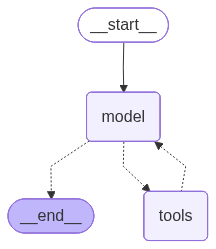

In [2]:
from langchain_groq import ChatGroq
from langchain.agents import create_agent

def weather (city:str)->str:
    """Get the weather of city"""                  # Docstring is needed , else error will arise
    return f"The weather in {city} is sunny."

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY").strip()
)

agent = create_agent(
    model=llm,
    tools=[weather],
    system_prompt="You are a helpful assistant"
)

agent

In [3]:
response = agent.invoke({"messages":[{"role":"user" , "content":"what is the weather of new york city ?"}]})

In [4]:
response["messages"]

[HumanMessage(content='what is the weather of new york city ?', additional_kwargs={}, response_metadata={}, id='0f4504d0-977d-477c-92ba-84ea4e00d487'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ztgcq12h9', 'function': {'arguments': '{"city":"new york city"}', 'name': 'weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 222, 'total_tokens': 238, 'completion_time': 0.056767453, 'completion_tokens_details': None, 'prompt_time': 0.016685973, 'prompt_tokens_details': None, 'queue_time': 0.071093047, 'total_time': 0.073453426}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e86d3-41e7-74f0-8016-1fe1a396220c-0', tool_calls=[{'name': 'weather', 'args': {'city': 'new york city'}, 'id': 'ztgcq12h9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inp

In [61]:
agent.invoke({"messages":"what is the weather of india"})

{'messages': [HumanMessage(content='what is the weather of india', additional_kwargs={}, response_metadata={}, id='66882cef-4d22-45a6-b94e-9e4a9cabdabd'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5e7rqwjn7', 'function': {'arguments': '{"city":"India"}', 'name': 'weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 219, 'total_tokens': 233, 'completion_time': 0.065684491, 'completion_tokens_details': None, 'prompt_time': 0.02359652, 'prompt_tokens_details': None, 'queue_time': 0.180425049, 'total_time': 0.089281011}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e824f-0682-79a1-970f-de24c51d1b0d-0', tool_calls=[{'name': 'weather', 'args': {'city': 'India'}, 'id': '5e7rqwjn7', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2

# Models Integration with LLM

## Gemini model

In [6]:
from dotenv import load_dotenv
import os
load_dotenv()


os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

In [10]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
        "google_genai:gemini-2.5-flash-lite"       # Give no spaces here
        )

response = model.invoke("Why do parratos talk ?")
print(response.content)

The word "parratos" is not a commonly recognized term in the English language. It's possible it's a misspelling or a term from a specific dialect or context. To give you the most accurate answer, could you please clarify what "parratos" refers to?

However, if you're asking about **parrots** (which sounds very similar and is a common word), here's why they talk:

Parrots are renowned for their ability to mimic sounds, including human speech. This remarkable ability stems from a combination of factors:

*   **Vocal Anatomy:** Parrots possess a specialized vocal organ called the **syrinx**. This organ is located at the base of their trachea (windpipe) and is much more complex than the larynx found in mammals. The syrinx allows parrots to produce a wide range of sounds and control their pitch and tone with great precision.
*   **Brain Structure and Intelligence:** Parrots are highly intelligent birds. They have a relatively large brain-to-body size ratio and exhibit advanced cognitive abi

## Groq model


In [13]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("How are you ?")
print(response.content)

<think>
Let me think carefully about this greeting. The user is asking "How are you?" which is a very common open-ended question. I need to consider how best to respond in a way that's authentic while also being helpful.

First, I should acknowledge the greeting in a friendly manner. I want to be sincere about my capabilities - I can process information and generate responses, but I don't experience feelings in the way humans do. It's important to be clear about this distinction.

At the same time, I want to keep the conversation moving forward. Rather than getting stuck on the technicalities of my nature, I should focus on how I can be useful to the user. I can let them know I'm ready to help with whatever they need, whether it's finding information, solving problems, or just having an interesting discussion.

I should also consider the emotional aspect of this question. When people ask "How are you?" they're often showing interest in others. I can respond in a way that acknowledges t

# Streaming and Batch

In [ ]:
for chunks in model.stream("Provide me with 300 words on AI !") :
    print(chunks.text, end="")


<think>
Okay, the user asked for a 300-word summary on AI. Let me start by outlining the key points. First, I should define AI and mention its subfields like machine learning and deep learning. Then, maybe talk about some applications in different sectors such as healthcare, finance, and transportation. I need to highlight both the benefits and the challenges. Benefits include efficiency, automation, and solving complex problems. Challenges could be ethical issues, job displacement, and privacy concerns. Also, it's important to mention the current trends like generative AI and the importance of responsible development. I should make sure the language is clear and concise, avoiding technical jargon so it's accessible. Let me check the word count as I go. Start with an introduction, then structure the paragraphs around applications, challenges, and future outlook. Maybe include examples like medical diagnostics or self-driving cars to illustrate points. Conclude by emphasizing the need f

In [20]:
model.batch (
    [
        "Why do im alive ?",
        "What is meant by world ?",
        "What is why ?"
    ],
    config= {
        'max_concurrency':5,
    }
)

[AIMessage(content='<think>\nOkay, the user is asking, "Why do I\'m alive?" That\'s a big question. Let me start by understanding the context. They might be feeling existential or philosophical, maybe going through a tough time. I should approach this with empathy.\n\nFirst, I need to acknowledge their question seriously. People ask this for various reasons—searching for meaning, dealing with life\'s challenges, or just curiosity. I should consider different perspectives: scientific, philosophical, religious, and personal.\n\nFrom a scientific angle, existence is due to biological processes and evolution. But that might not satisfy someone looking for meaning. Philosophically, existentialists say we create our own purpose. Religious views often involve a divine purpose. Then there\'s the personal aspect—individual goals and relationships.\n\nI should also think about how to phrase the response. Avoid being too technical if they\'re not looking for science. Maybe offer multiple viewpoin

# Tool calling

In [ ]:
from langchain.tools import tool

@tool
def weather (location:str):
    """Get the weather of the asked location"""
    return f"The weather of {location} is rainy"

model_with_tool = model.bind_tools([weather])

response = model_with_tool.invoke("What is the weather at boston ?")
print(response)

# Till here , the llm has requested to call the tool and the response is not generated yet.

content='' additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in Boston. I need to use the weather function provided. The function requires a location parameter. Boston is the location they mentioned. I should call the weather function with "Boston" as the argument. Let me make sure the JSON is formatted correctly with the location parameter. No other parameters are needed. Alright, that should get the current weather for Boston.\n', 'tool_calls': [{'id': 'zn3gz1p74', 'function': {'arguments': '{"location":"Boston"}', 'name': 'weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 154, 'total_tokens': 257, 'completion_time': 0.193427655, 'completion_tokens_details': {'reasoning_tokens': 80}, 'prompt_time': 0.006377145, 'prompt_tokens_details': None, 'queue_time': 0.052225015, 'total_time': 0.1998048}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 

## Tool execution loop

In [24]:
messages = [{"role" : "user"  , "content":"What is the weather at delhi ?"}]
ai_msg = model_with_tool.invoke(messages)
messages.append(ai_msg)

for tool_call in ai_msg.tool_calls:
    tool_result = weather.invoke(tool_call)
    messages.append(tool_result)

response = model_with_tool.invoke(messages)
print(response.text)

The current weather in Delhi is rainy. You might want to carry an umbrella if you're heading out! 🌧️


# Messages

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model (
    "groq:qwen/qwen3-32b"
)

response = model.invoke("HI !")


In [36]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage('You are a poetry expert'),
    HumanMessage("Write a poem on aritificial intelligence") 
]

response = model.invoke(messages)
response.content

'<think>\nOkay, the user wants a poem about artificial intelligence. Let me start by brainstorming some key themes related to AI. There\'s the creation aspect—how humans build AI. Then, the duality of AI being both beneficial and potentially dangerous. Maybe touch on emotions versus machines. Also, the future implications.\n\nI need to decide on a structure. Maybe a traditional rhyme scheme to make it flow smoothly. Let\'s go with quatrains, maybe an ABAB rhyme scheme. That\'s common and gives a good rhythm.\n\nFirst stanza could introduce AI as a creation. Use imagery like circuits and code. Words like "child of silicon and stardust" to blend the tech with something ethereal. Mention learning from data and human input.\n\nNext, the second stanza can address the purpose of AI—solving problems, medical advancements, space exploration. But also hint at the ethical side, like privacy and autonomy. Use words like "guardian" and "shadow" to show contrasts.\n\nThird stanza could explore the 

In [37]:
from langchain_core.messages import ToolMessage
# After a model makes a tool call
# (Here, we demonstrate manually creating the messages for brevity)
ai_message = AIMessage(
content=[],
tool_calls=[{
    "name": "get_weather",
    "args": {"location": "San Francisco"},
    "id": "call_123"
    }]
)


# Execute tool and create result message
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id="call_123" # Must match the call ID
)


# Continue conversation
messages = [
    HumanMessage("What's the weather in San Francisco?"),
    ai_message, # Model's tool call
    tool_message,
]

In [38]:
response = model.invoke(messages)

In [39]:
response.content

'<think>\nOkay, the user asked for the weather in San Francisco, and I called the get_weather function with the location set to San Francisco. The response came back as "Sunny, 72°F". Now I need to present this information in a friendly and helpful way.\n\nFirst, I should confirm the location to make sure there\'s no confusion. Then, state the current weather condition and temperature clearly. Maybe add a suggestion based on the weather, like mentioning it\'s a good day to be outdoors since it\'s sunny. Keep the tone positive and concise. Let me put that together.\n</think>\n\nThe weather in San Francisco is currently **sunny** with a temperature of **72°F**. It\'s a perfect day to enjoy outdoor activities! ☀️'

# Structured Output

" When we want to print the output in our desired format "

## Pydantic

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model (
    "groq:qwen/qwen3-32b"
)
reponse = model.invoke("hey !")
print(reponse.text)

In [9]:
from pydantic import BaseModel, Field

class Movie( BaseModel ):
    title:str = Field(description="Title of the movie")
    year:int=Field(description="Year when the movie released")
    director:str=Field(description="The director of the movie")
    rating:float = Field(description="Rating for the movie")

In [12]:
model_with_structure = model.with_structured_output(Movie)
model_with_structure

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D67B18C410>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D67B18D310>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'description': 'Title of the movie', 'type': 'string'}, 'year': {'description': 'Year when the movie released', 'type': 'integer'}, 'director': {'description': 'The director of the movie', 'type': 'string'}, 'rating': {'description': 'Rating for the movie', 'type'

In [13]:
response = model_with_structure.invoke("Provide me with the details of movie avatar")

In [16]:
print(response)

title='Avatar' year=2009 director='James Cameron' rating=7.8


## Message output alongside parsed structure